In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("ai4i2020.csv")
display(df.shape)
display(df.head())
display(df.tail())
display(df.dtypes)

(10000, 14)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

14 cols and 10000 rows. 2 id columns.
no apparent null values

In [3]:
df.replace("?", np.nan, inplace=True)
display(df.describe())
display(df.isnull().sum())
display(df.info())

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

None

In [4]:
display(df.duplicated().sum())

np.int64(0)

no duplicate rows found


target column is Machine failure.

In [5]:
display(df['Machine failure'].value_counts())
display(df['Machine failure'].value_counts(normalize='True')*100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

only 3.39% of rows are failure rows. a model that always predicts "no failure" would still be 96.61% accurate, making accuracy a bad metric.
F1 score and Recall will be used.

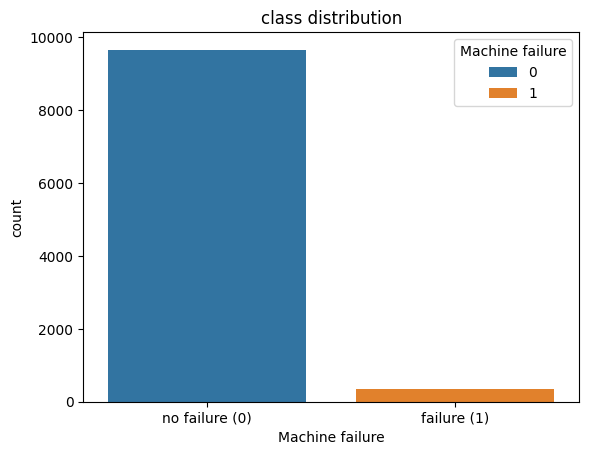

In [6]:
sns.countplot(x='Machine failure', data=df, hue='Machine failure')
plt.title('class distribution')
plt.xticks([0,1],['no failure (0)', 'failure (1)'])
plt.show()

In [7]:
display(df['Type'].value_counts())
display(df.groupby('Type')['Machine failure'].mean()*100)

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

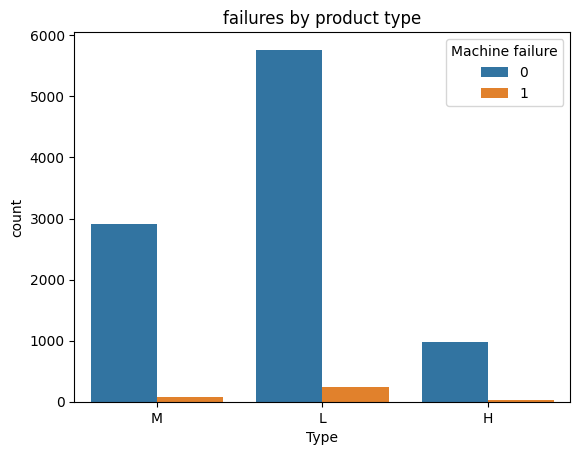

In [8]:
sns.countplot(x='Type', hue='Machine failure',data=df)
plt.title('failures by product type')
plt.show()

L type machines have slightly higher failure rates than M and H type.
overall failure rates: L>M>H

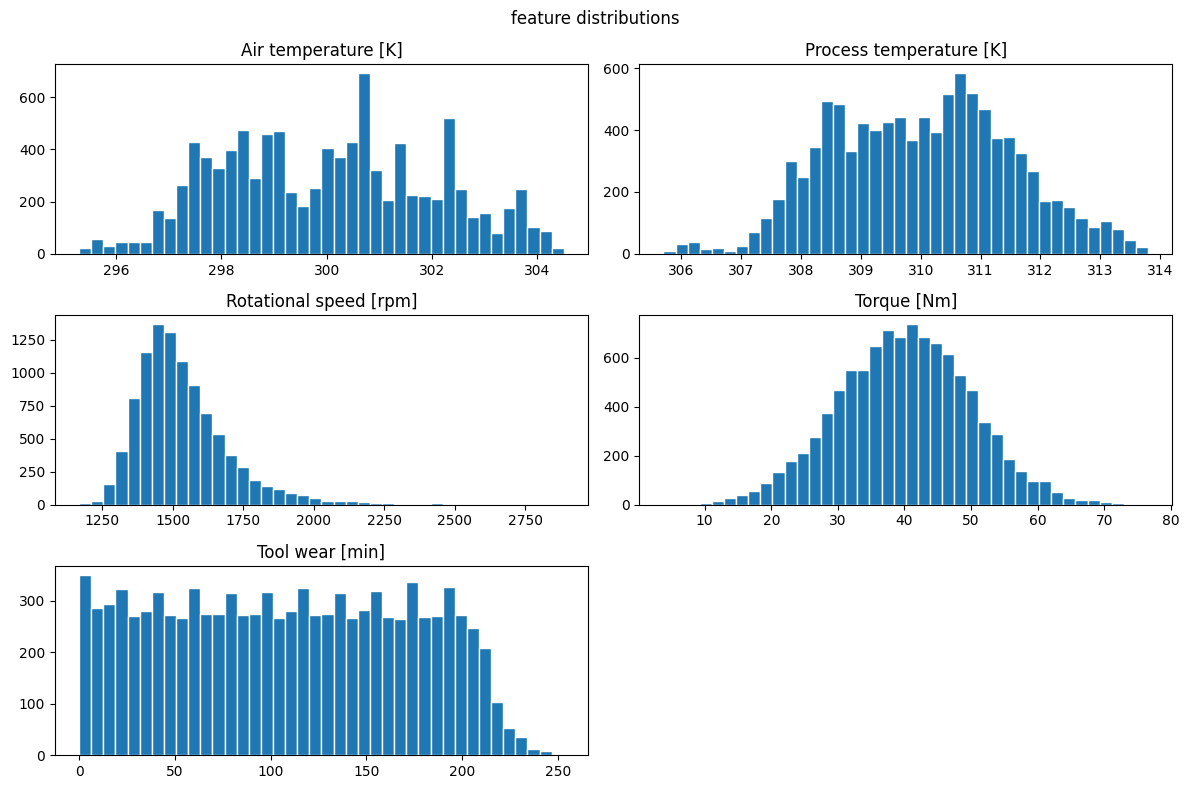

In [9]:
numeric_cols=['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df[numeric_cols].hist(bins=40, figsize=(12,8), grid=False, edgecolor='white')
plt.suptitle('feature distributions')
plt.tight_layout()
plt.show()

rotational speed is right skewed- most of the operation occurs at lower rpms.
tool wear in uniform and flat till 200, after which it falls abruptly.

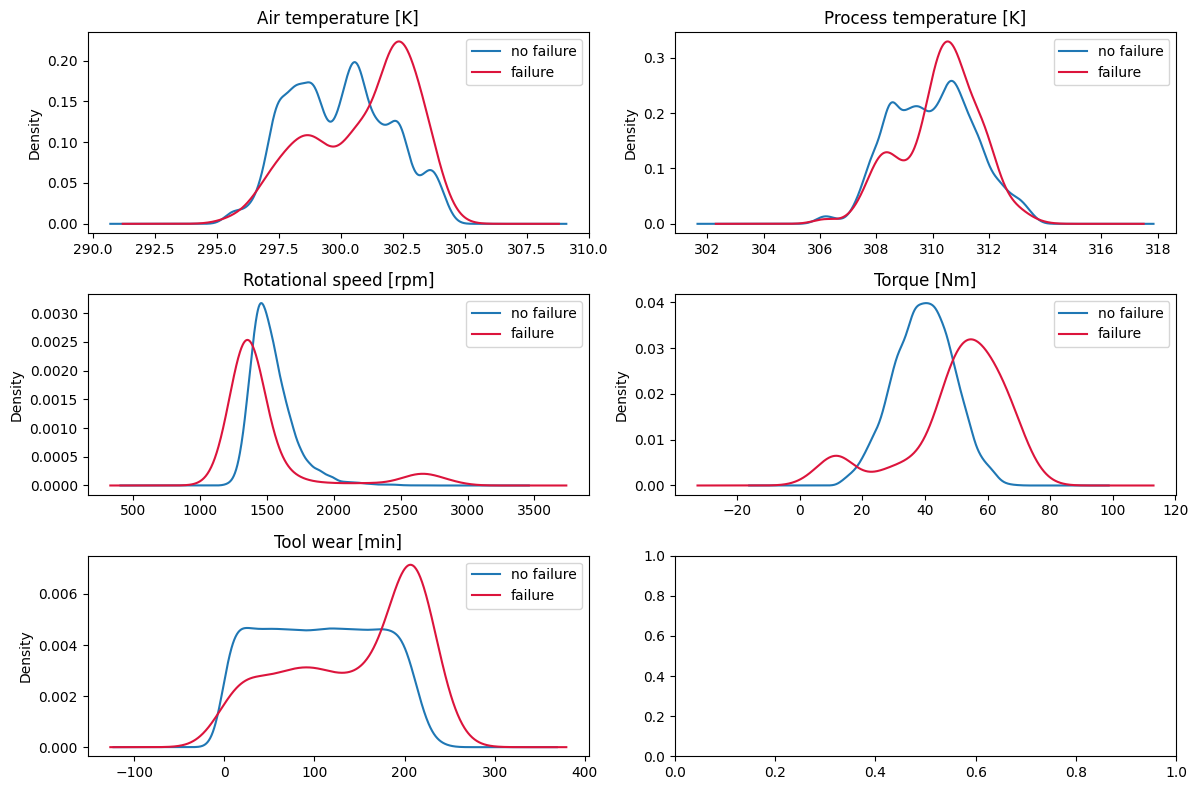

In [10]:
fig, axes=plt.subplots(3,2, figsize=(12,8))
axes=axes.flatten()

for i,col in enumerate(numeric_cols):
    df[df['Machine failure']==0][col].plot(kind='kde', ax=axes[i], label='no failure')
    df[df['Machine failure']==1][col].plot(kind='kde', ax=axes[i], label='failure', color='crimson')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

torque and tool wear show the clearest seperation between failure and no failure, so are probably the strongest features. air temperature and process temperature are mostly overlapping so are weak individual indicators.

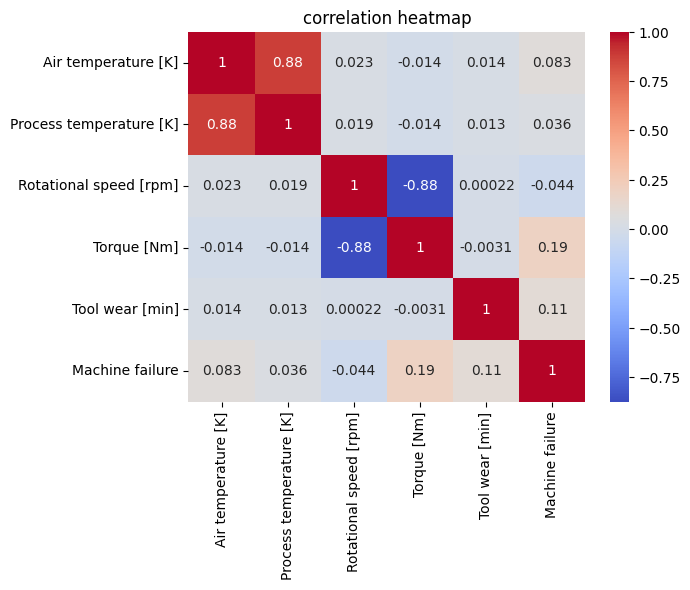

In [11]:
corr=df[numeric_cols+['Machine failure']].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('correlation heatmap')
plt.show()

there is a very low linear correlation between individual features and machine failure. therefore there is a need for a model like xgboost for combination of features.
strong correlation between air and process temp
strong negative correlation between speed and torque which is consistent with expected outcomes.
no need to drop any cols.

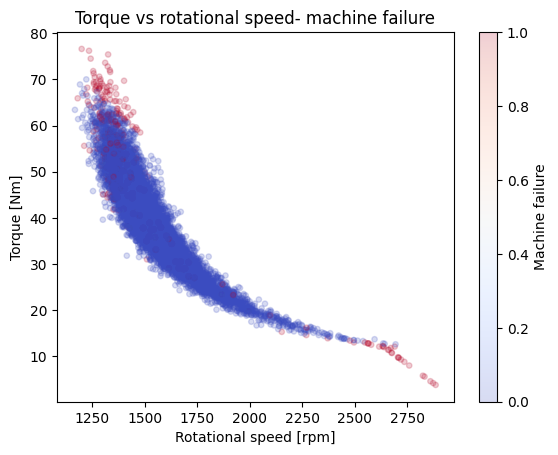

In [12]:
plt.scatter(df['Rotational speed [rpm]'], df['Torque [Nm]'], c=df['Machine failure'], cmap='coolwarm', alpha=0.2, s=15)
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.title('Torque vs rotational speed- machine failure')
plt.colorbar(label='Machine failure')
plt.show()

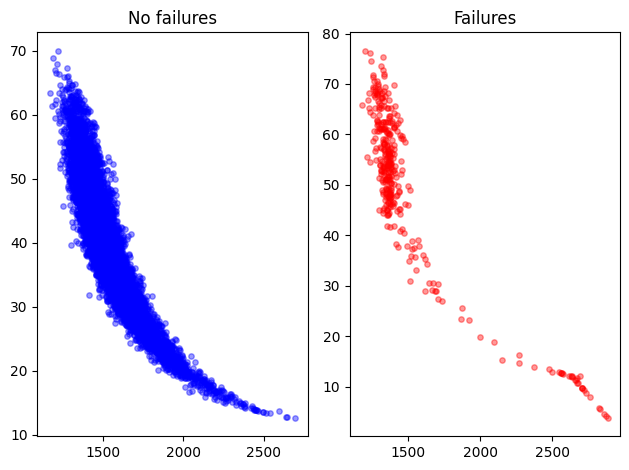

In [13]:
fig, axes=plt.subplots(1,2)
failures=df[df['Machine failure']==1]
nofailures=df[df['Machine failure']==0]

axes[0].scatter(nofailures['Rotational speed [rpm]'], nofailures['Torque [Nm]'], color='blue', alpha=0.4, s=15)
axes[1].scatter(failures['Rotational speed [rpm]'], failures['Torque [Nm]'], color='red', alpha=0.4, s=15)
axes[0].set_title('No failures')
axes[1].set_title('Failures')
plt.tight_layout()
plt.show()

no failures cluster at the middle power range. failures lie at extreme power values, confirming a non linear relationship.

In [14]:
failure_reasons=['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
display(df[failure_reasons].sum())
display(df[df['Machine failure']==0][failure_reasons].sum())

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64

these 5 cols are failure reasons, which are directly correlated to machine failure. including these in the training data will be data leakage and will directly give the answer to the model, and no real pattern will be learnt.
HDF, PWF AND OSF are most common reaons for failure which is consistent with torque*rotational speed (ie. extreme power range failures).

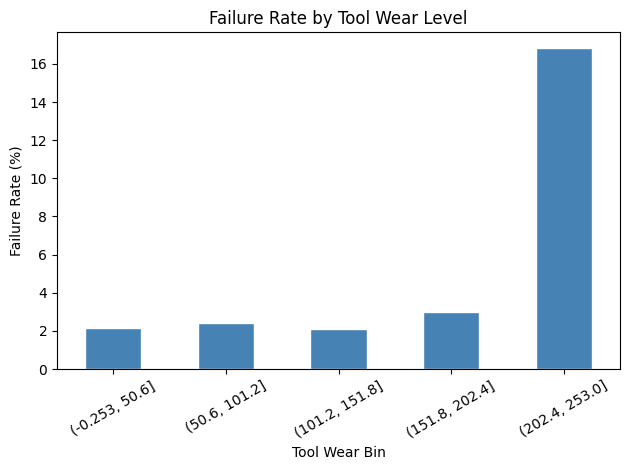

In [15]:
df['wear_bin'] = pd.cut(df['Tool wear [min]'], bins=5)
wear_failure = df.groupby('wear_bin')['Machine failure'].mean() * 100

wear_failure.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Failure Rate by Tool Wear Level')
plt.ylabel('Failure Rate (%)')
plt.xlabel('Tool Wear Bin')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

df.drop('wear_bin', axis=1, inplace=True)

failure rate increases by a significant amount- from 2% to over 16% after tool wear crosses 200mins

## EDA Summary

1. The dataset is highly imbalanced, with only 3.4% failure cases. A model predicting only "No Failure" achieves 96.6% accuracy, so accuracy alone is not a reliable metric. Recall and F1 score are more important for this problem.

2. Tool wear and torque show the clearest differences between failure and non-failure cases. Machines with higher tool wear and torque tend to fail more often.

3. Rotational speed and torque are strongly negatively correlated. Failures appear at extreme operating conditions, suggesting that the relationship between features is not purely linear.

4. Air temperature and process temperature are highly correlated and show significant overlap between classes. Individually they are weak predictors, but they were retained for tree-based models.

5. Failure rate increases noticeably as tool wear increases, especially beyond 200 minutes, indicating a strong relationship between wear and machine failure.

6. The columns TWF, HDF, PWF, OSF and RNF directly indicate failure types and leak information about the target. These columns were removed before model training.